# Artifact Rejection

## 1. Historical Context of EEG
---


*   **1929:** Hans Berger recorded the first human **electroencephalogram (EEG)**, discovering the alpha wave.
*   **1960s:** The **computerization** of EEG 

## 2. Introduction to EEG Signals
---
### What is EEG?
EEG signals are inherently **non-stationary**, meaning their statistical properties (like mean and variance) change over time. 

> **Definition:** Electroencephalography is the measurement, amplification, and registration of fluctuating electrical fields produced by the brain as a function of time.

#### The Spatio-Temporal Trade-off
EEG is characterized by its **high temporal resolution** (capturing changes in milliseconds) but lacks **spatial resolution** (difficulty pinpointing the exact cortical source of a signal).



#### EEG Artifacts
The primary challenge in EEG analysis is the presence of **artifacts**—signals not originating from the brain. Common examples include:
*   **Eyeblinks**
*   **Eye movements**
*   **Muscle movements (EMG)**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider

# --- Generate Signals ---
np.random.seed(42)
fs = 256  # Sampling frequency
t = np.linspace(0, 4, fs * 4)

# Stationary signal: fixed 10 Hz sine + constant noise
stationary = np.sin(2 * np.pi * 10 * t) + 0.3 * np.random.randn(len(t))

# Non-stationary signal: frequency & amplitude change over time (like real EEG)
non_stationary = (
    np.sin(2 * np.pi * 8 * t) * (1 + 0.5 * np.sin(2 * np.pi * 0.5 * t))  # alpha with amplitude modulation
    + np.where((t > 1.5) & (t < 2.5), 3 * np.sin(2 * np.pi * 2 * t), 0)  # transient artifact burst
    + 0.3 * np.random.randn(len(t))
)

def plot_signals(window_center=2.0, window_size=80):
    """Slide a window across both signals to inspect local statistics."""
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

    start = max(0, int(window_center * fs) - window_size // 2)
    end = min(len(t), start + window_size)
    
    for ax, sig, title in zip(axes, [stationary, non_stationary],
                               ["Stationary Signal (10 Hz + noise)",
                                "Non-Stationary Signal (modulated alpha + artifact burst)"]):
        ax.plot(t, sig, color="steelblue", alpha=0.6, linewidth=0.8)
        ax.axvspan(t[start], t[end - 1], color="orange", alpha=0.25, label="window")
        
        # Show local mean & std in the window
        local_mean = np.mean(sig[start:end])
        local_std = np.std(sig[start:end])
        ax.axhline(local_mean, color="red", linestyle="--", linewidth=1.2)
        ax.set_title(f"{title}  |  window μ={local_mean:.2f}, σ={local_std:.2f}", fontsize=11)
        ax.set_ylabel("Amplitude (μV)")
        ax.legend(loc="upper right", fontsize=9)
    
    axes[1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

interact(
    plot_signals,
    window_center=FloatSlider(min=0.2, max=3.8, step=0.1, value=2.0, description="Center (s)"),
    window_size=IntSlider(min=30, max=256, step=10, value=80, description="Window size"),
)

interactive(children=(FloatSlider(value=2.0, description='Center (s)', max=3.8, min=0.2), IntSlider(value=80, …

<function __main__.plot_signals(window_center=2.0, window_size=80)>

# 3. Artifact Rejection: Regression & Filtering
---
### 1. Regression-based Methods
Traditionally, regression and linear filtering-based analyses are employed to reject artifactual noises from corrupted signals.

*   **Mechanism:** These methods rely on extra regressive channels (like an EOG channel) to "subtract" noise.
*   **Weakness:** A fundamental weakness is that the **spectral range** of some artifacts overlaps with the spectral range of the actual EEG signal, potentially leading to the loss of real neural data.

# 4. The Wavelet Transform (WT)
---
Transforming a time-domain signal into the **time-frequency domain** offers major advantages in extracting multiple components of a signal.

The wavelet transform decomposes a time-domain signal into its **wavelet coefficients** through a **mother wavelet function**. These coefficients are obtained by performing shifting and dilation of the mother wavelet:

$$ \Psi_{a,b}(t) = \Psi \left( \frac{t-b}{a} \right) $$

Where:
*   **$a$**: The scaling parameter.
*   **$b$**: The shifting parameter.

#### Types of Wavelet Transform
1.  **Discrete Wavelet Transform (DWT)**
2.  **Continuous Wavelet Transform (CWT)**
3.  **Stationary Wavelet Transform (SWT)**

The coefficients are modified by taking advantage of their local properties, and the transformation is then inverted to obtain a clean version of the signal.

> **Intuition - The Choice of Wavelet:** 
> Choice of wavelet matters. Imagine zooming in and out of a signal with differently stretched oscillatory lenses. You want to pick a "lens" (mother wavelet) that most closely mirrors the shape of the feature (e.g., a blink or a spike) you are trying to isolate.

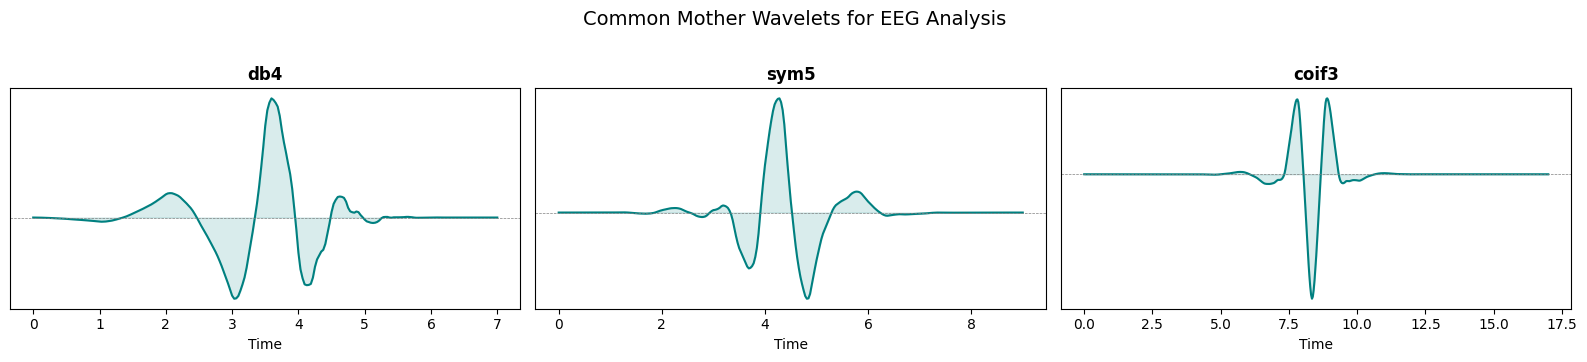

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# --- Visualise common mother wavelets used in EEG ---
wavelet_names = ["db4", "sym5", "coif3"]
fig, axes = plt.subplots(1, len(wavelet_names), figsize=(16, 3.5))

for ax, name in zip(axes, wavelet_names):
    try:
        wav = pywt.ContinuousWavelet(name)
        # For continuous wavelets use pywt's wavefun
        [psi, x] = wav.wavefun(precision=10)
    except Exception:
        wav = pywt.Wavelet(name)
        [phi, psi, x] = wav.wavefun(level=5)[:3]
    
    ax.plot(x, psi, color="teal", linewidth=1.5)
    ax.fill_between(x, psi, alpha=0.15, color="teal")
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_xlabel("Time")
    ax.set_yticks([])

fig.suptitle("Common Mother Wavelets for EEG Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

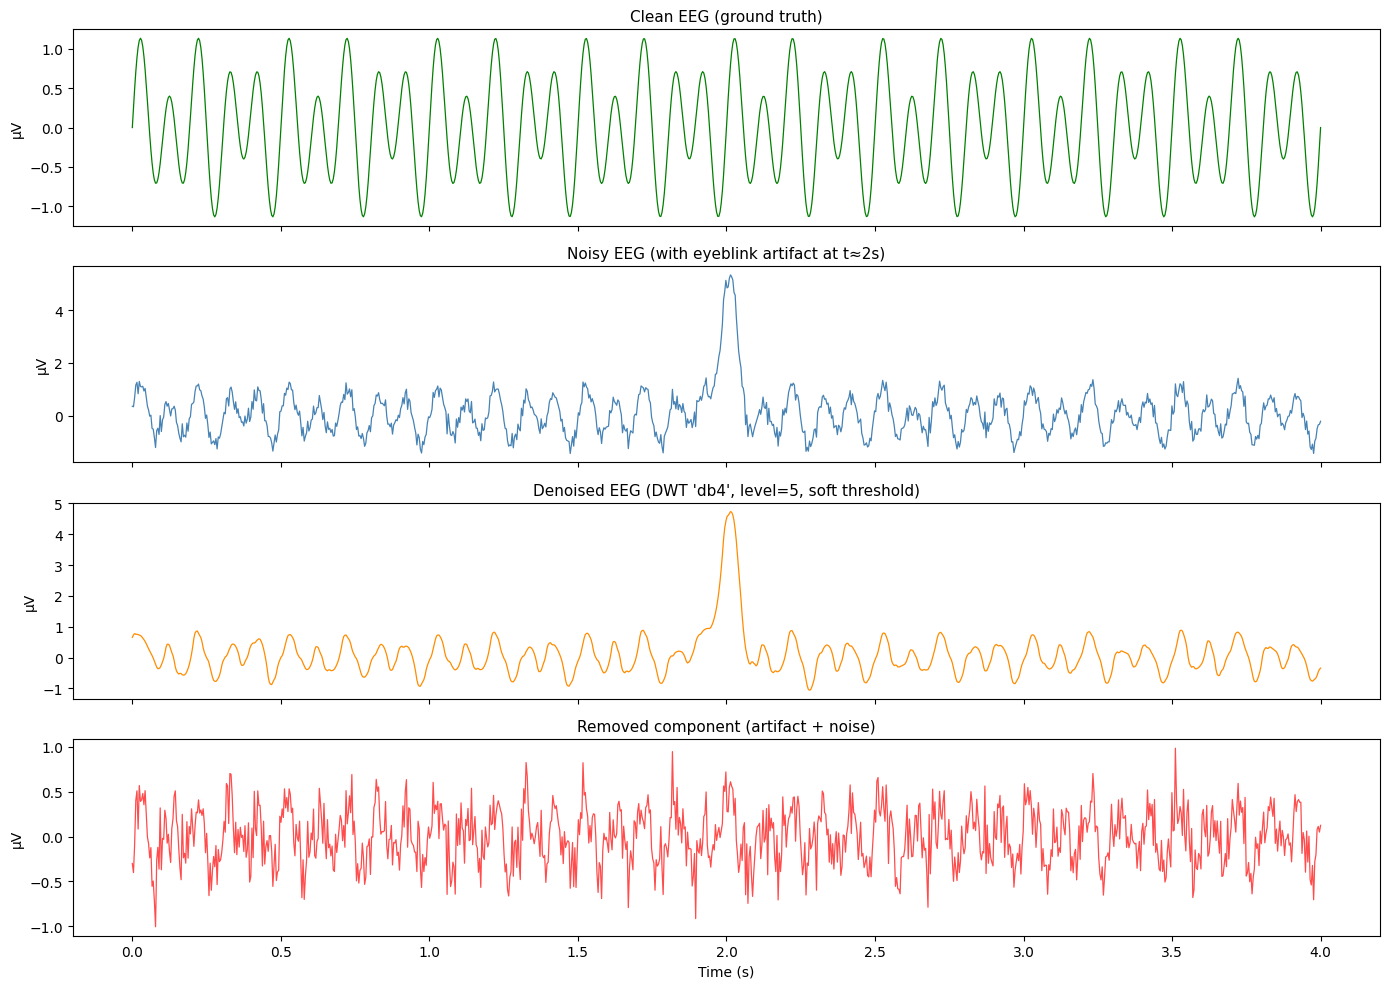

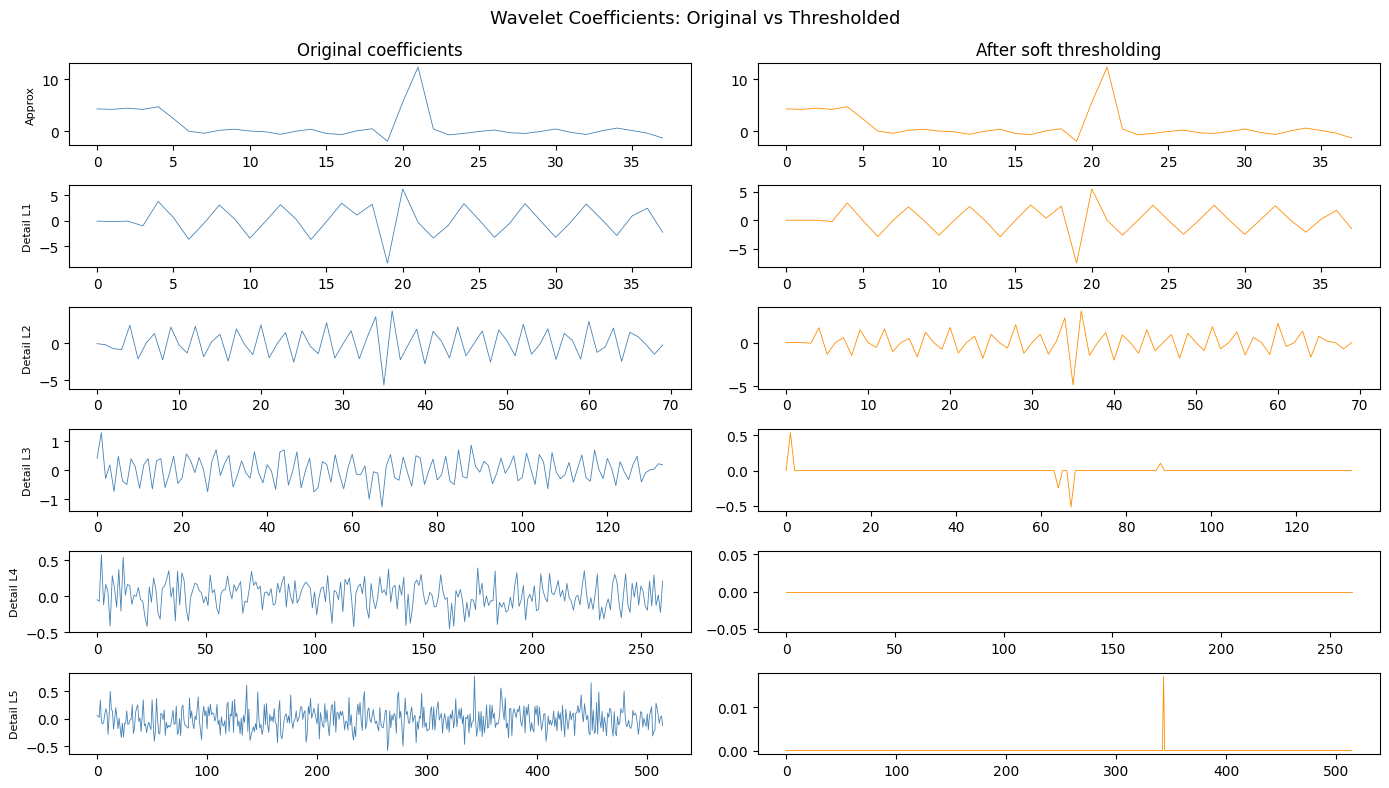

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# --- Create a synthetic EEG-like signal with an eyeblink artifact ---
np.random.seed(0)
fs = 256
t = np.linspace(0, 4, fs * 4)

# Clean EEG: alpha (10 Hz) + beta (20 Hz)
clean_eeg = 0.8 * np.sin(2 * np.pi * 10 * t) + 0.4 * np.sin(2 * np.pi * 6* t)

# Eyeblink artifact: a broad Gaussian bump around t=2s
blink = 5 * np.exp(-((t - 2.0) ** 2) / (2 * 0.03**2))

# Noisy signal
noisy_eeg = clean_eeg + blink + 0.2 * np.random.randn(len(t))

# --- DWT Denoising with soft thresholding ---
wavelet = "db4"
level = 5
coeffs = pywt.wavedec(noisy_eeg, wavelet, level=level)

# Estimate noise std from the finest detail coefficients (MAD estimator)
sigma = np.median(np.abs(coeffs[-1])) / 0.6745
threshold = sigma * np.sqrt(2 * np.log(len(noisy_eeg)))  # Universal threshold

# Apply soft thresholding to detail coefficients (keep approximation)
coeffs_thresh = [coeffs[0]] + [pywt.threshold(c, value=threshold, mode="soft") for c in coeffs[1:]]
denoised_eeg = pywt.waverec(coeffs_thresh, wavelet)[:len(t)]

# --- Plot results ---
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(t, clean_eeg, color="green", linewidth=0.9)
axes[0].set_title("Clean EEG (ground truth)", fontsize=11)

axes[1].plot(t, noisy_eeg, color="steelblue", linewidth=0.9)
axes[1].set_title("Noisy EEG (with eyeblink artifact at t≈2s)", fontsize=11)

axes[2].plot(t, denoised_eeg, color="darkorange", linewidth=0.9)
axes[2].set_title(f"Denoised EEG (DWT '{wavelet}', level={level}, soft threshold)", fontsize=11)

axes[3].plot(t, noisy_eeg - denoised_eeg, color="red", linewidth=0.9, alpha=0.7)
axes[3].set_title("Removed component (artifact + noise)", fontsize=11)
axes[3].set_xlabel("Time (s)")

for ax in axes:
    ax.set_ylabel("μV")
plt.tight_layout()
plt.show()

# --- Show wavelet coefficients before & after thresholding ---
fig2, axes2 = plt.subplots(level + 1, 2, figsize=(14, 8))
fig2.suptitle("Wavelet Coefficients: Original vs Thresholded", fontsize=13)

labels = ["Approx"] + [f"Detail L{i}" for i in range(1, level + 1)]
for i, (orig, thresh, label) in enumerate(zip(coeffs, coeffs_thresh, labels)):
    axes2[i, 0].plot(orig, color="steelblue", linewidth=0.6)
    axes2[i, 0].set_ylabel(label, fontsize=8)
    axes2[i, 1].plot(thresh, color="darkorange", linewidth=0.6)
    if i == 0:
        axes2[i, 0].set_title("Original coefficients")
        axes2[i, 1].set_title("After soft thresholding")

plt.tight_layout()
plt.show()

# 5. Empirical Mode Decomposition (EMD)
---
Unlike Wavelet Transforms which use predefined basis functions, **EMD** is a data-driven approach. It discovers oscillatory modes directly from the signal itself.

### What are IMFs?
EMD decomposes a signal into **Intrinsic Mode Functions (IMFs)**. Each IMF is:
*   **Locally symmetric**
*   **Narrow-band-ish**
*   **Oscillatory**

The signal is represented as:
$$\text{Signal} = \sum_{i=1}^{n} \text{IMF}_i + \text{residual}$$

### Why use EMD for EEG?
*   **No Assumptions:** It does not assume sinusoids (like Fourier) or wavelets.
*   **Biological Fit:** Modes emerge from the signal, making it ideal for **neural oscillations** which are often messy, non-linear, and non-stationary.

### The Major Issue: Mode Mixing
A common problem in EMD is **Mode Mixing**, where:
1.  A single IMF contains multiple disparate frequencies.
2.  A single frequency component is split across multiple IMFs.
*This is especially prevalent in noisy data.*

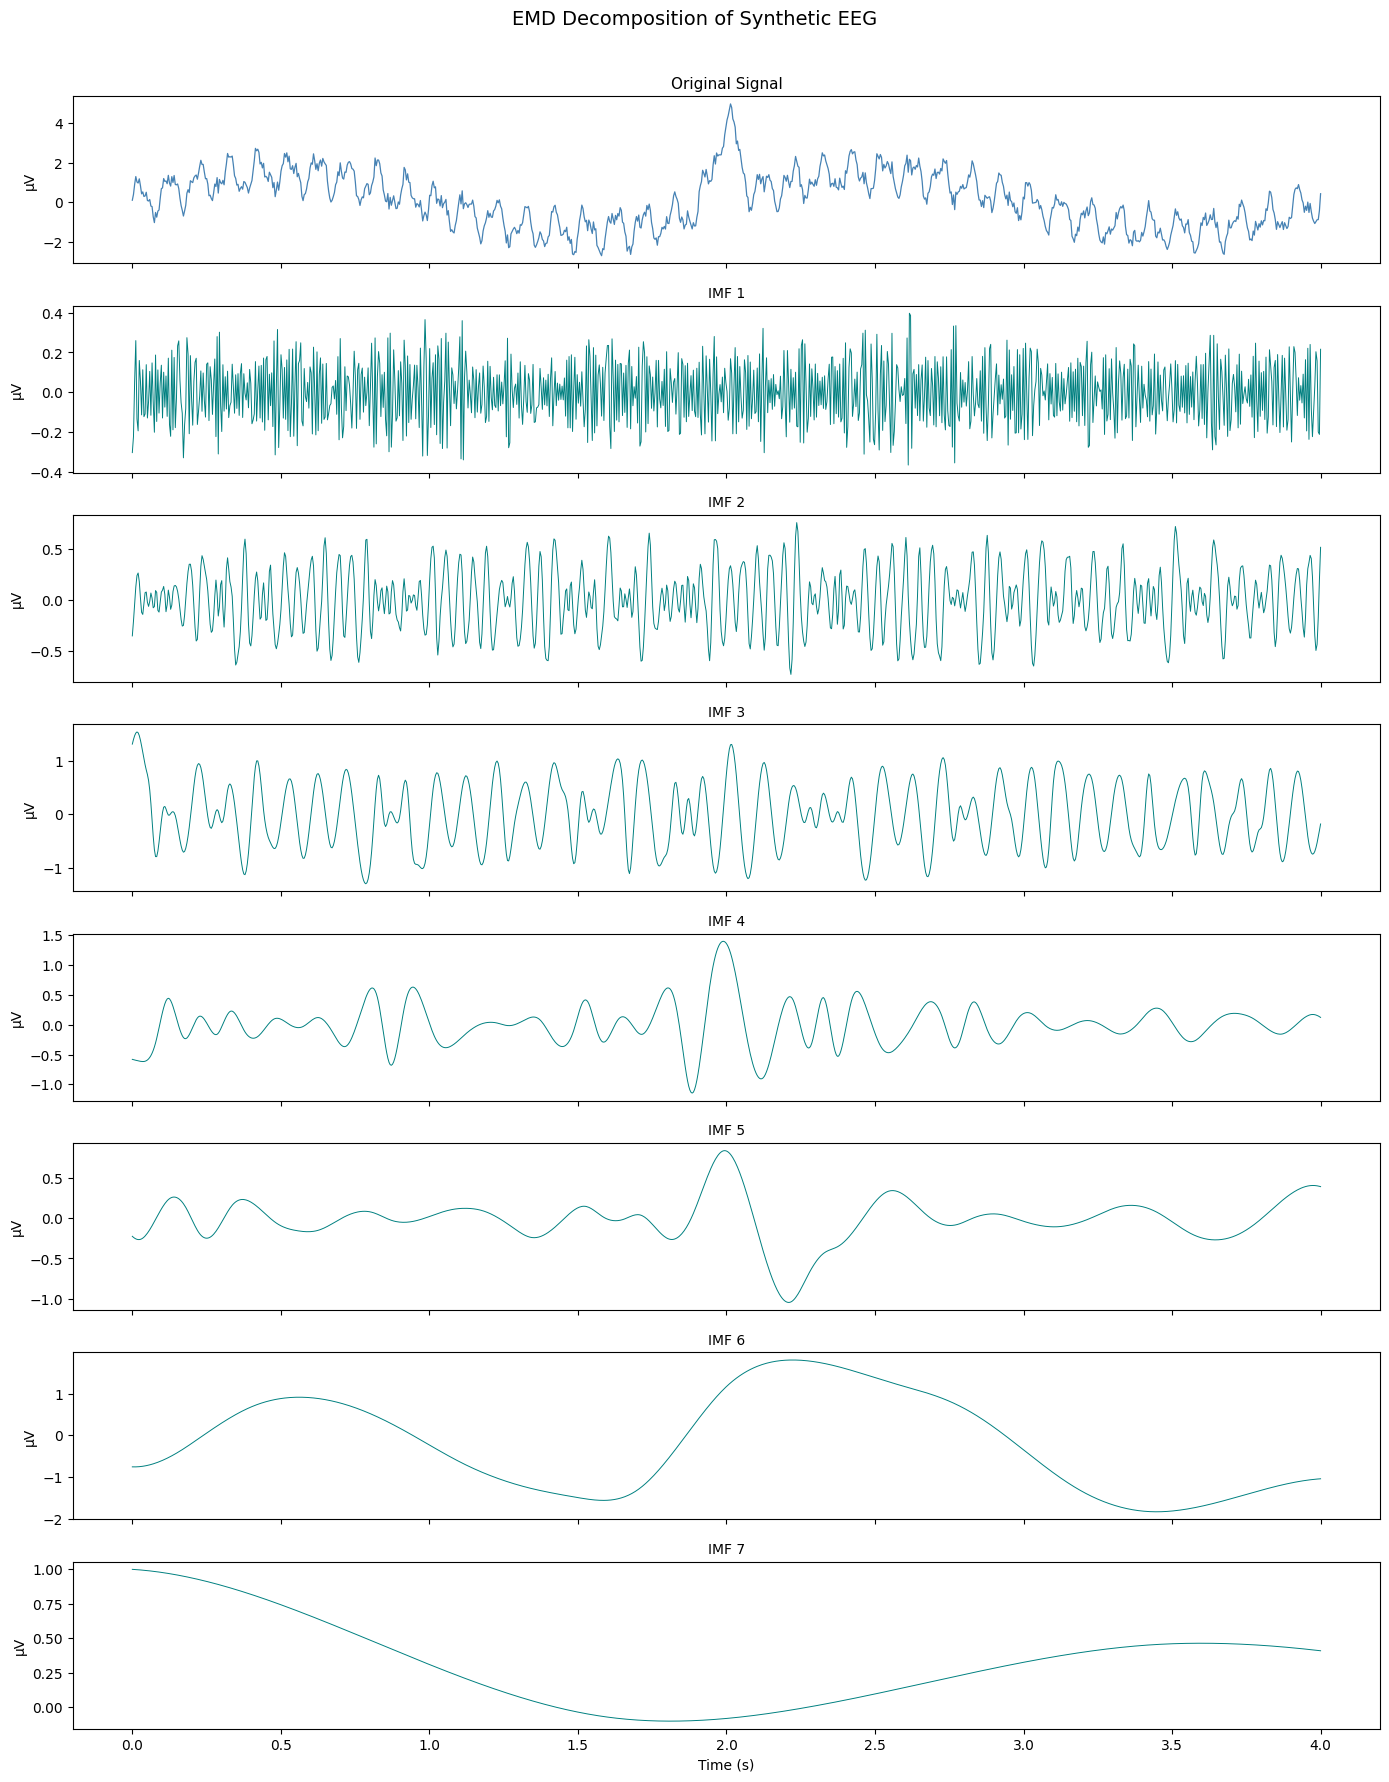

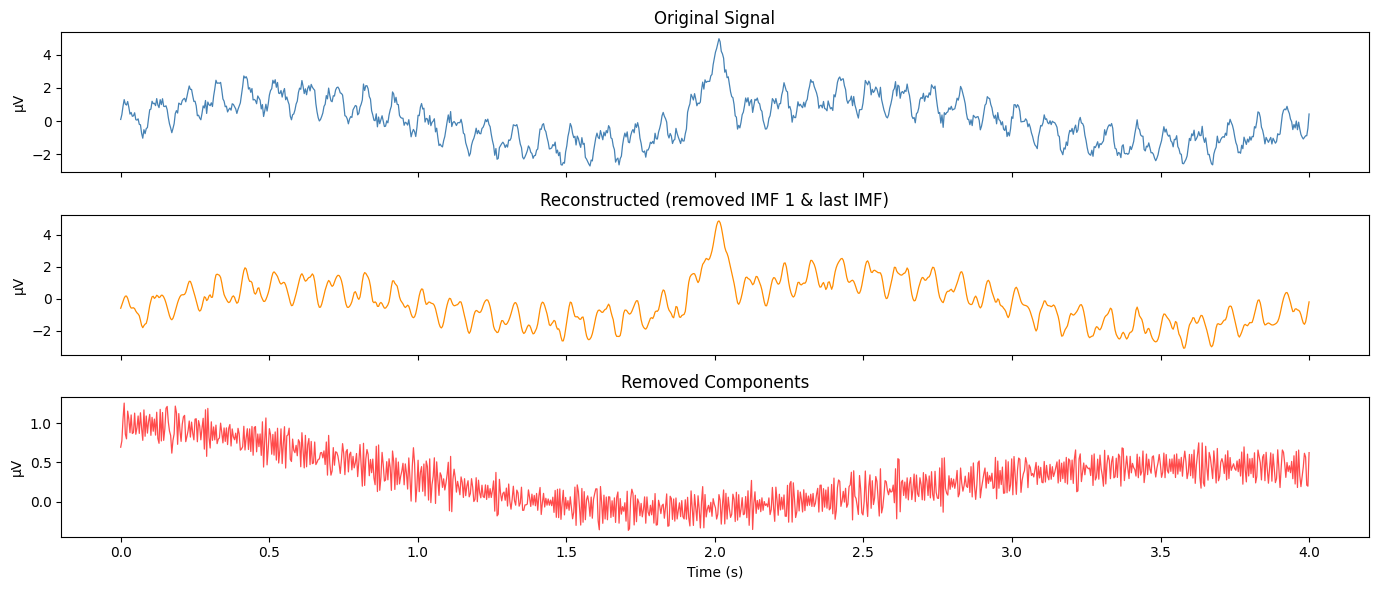

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from PyEMD import EMD

# --- Create a synthetic EEG-like signal ---
np.random.seed(42)
fs = 256
t = np.linspace(0, 4, fs * 4)

# Multi-component signal: alpha + slow drift + artifact
signal = (
    0.8 * np.sin(2 * np.pi * 10 * t)                     # Alpha rhythm
    + 0.4 * np.sin(2 * np.pi * 22 * t)                    # Beta rhythm
    + 1.5 * np.sin(2 * np.pi * 0.5 * t)                   # Slow drift / DC artifact
    + 4 * np.exp(-((t - 2.0) ** 2) / (2 * 0.04**2))       # Blink artifact
    + 0.2 * np.random.randn(len(t))                        # Noise
)

# --- Run EMD ---
emd = EMD()
imfs = emd.emd(signal, t)

# --- Plot the signal and its IMFs ---
n_imfs = imfs.shape[0]
fig, axes = plt.subplots(n_imfs + 1, 1, figsize=(14, 2.2 * (n_imfs + 1)), sharex=True)

axes[0].plot(t, signal, color="steelblue", linewidth=0.9)
axes[0].set_title("Original Signal", fontsize=11)
axes[0].set_ylabel("μV")

for i in range(n_imfs):
    axes[i + 1].plot(t, imfs[i], color="teal", linewidth=0.7)
    axes[i + 1].set_title(f"IMF {i + 1}", fontsize=10)
    axes[i + 1].set_ylabel("μV")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("EMD Decomposition of Synthetic EEG", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# --- Reconstruct without artifact-heavy IMFs ---
# Typically the first IMF captures high-freq noise, and the last captures slow drift
# Remove IMF 1 (noise) and last IMF (drift) as a simple demo
clean_imfs = imfs[1:-1]
reconstructed = np.sum(clean_imfs, axis=0)

fig2, axes2 = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
axes2[0].plot(t, signal, color="steelblue", linewidth=0.9)
axes2[0].set_title("Original Signal")
axes2[1].plot(t, reconstructed, color="darkorange", linewidth=0.9)
axes2[1].set_title("Reconstructed (removed IMF 1 & last IMF)")
axes2[2].plot(t, signal - reconstructed, color="red", linewidth=0.9, alpha=0.7)
axes2[2].set_title("Removed Components")
for ax in axes2:
    ax.set_ylabel("μV")
axes2[2].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

# 6. Improving EMD: EEMD & CEEMDAN
---
To solve the "Mode Mixing" problem, we use ensemble-based approaches that leverage noise to stabilize the decomposition.

### A. Ensemble EMD (EEMD)
Counterintuitively, **adding noise improves robustness**. 
*   **How it works:** We add random white noise to the signal many times. For each noisy realization, we run EMD and then average the corresponding IMFs.
*   **Intuition:** Noise fills the time-frequency space uniformly, which helps "guide" the decomposition and prevents frequencies from hopping between modes.

**The Workflow:**
1. $x(t) + w_i(t)$ (Add noise)
2. Run EMD repeatedly to get $IMF_i^{(k)}$
3. $\bar{IMF}_i$ (Average results)

### B. CEEMDAN
**Complete Ensemble EMD with Adaptive Noise (CEEMDAN)** is a further refinement. It uses complementary positive and negative noise pairs to reduce reconstruction error and computational cost, providing a more complete and stable decomposition.

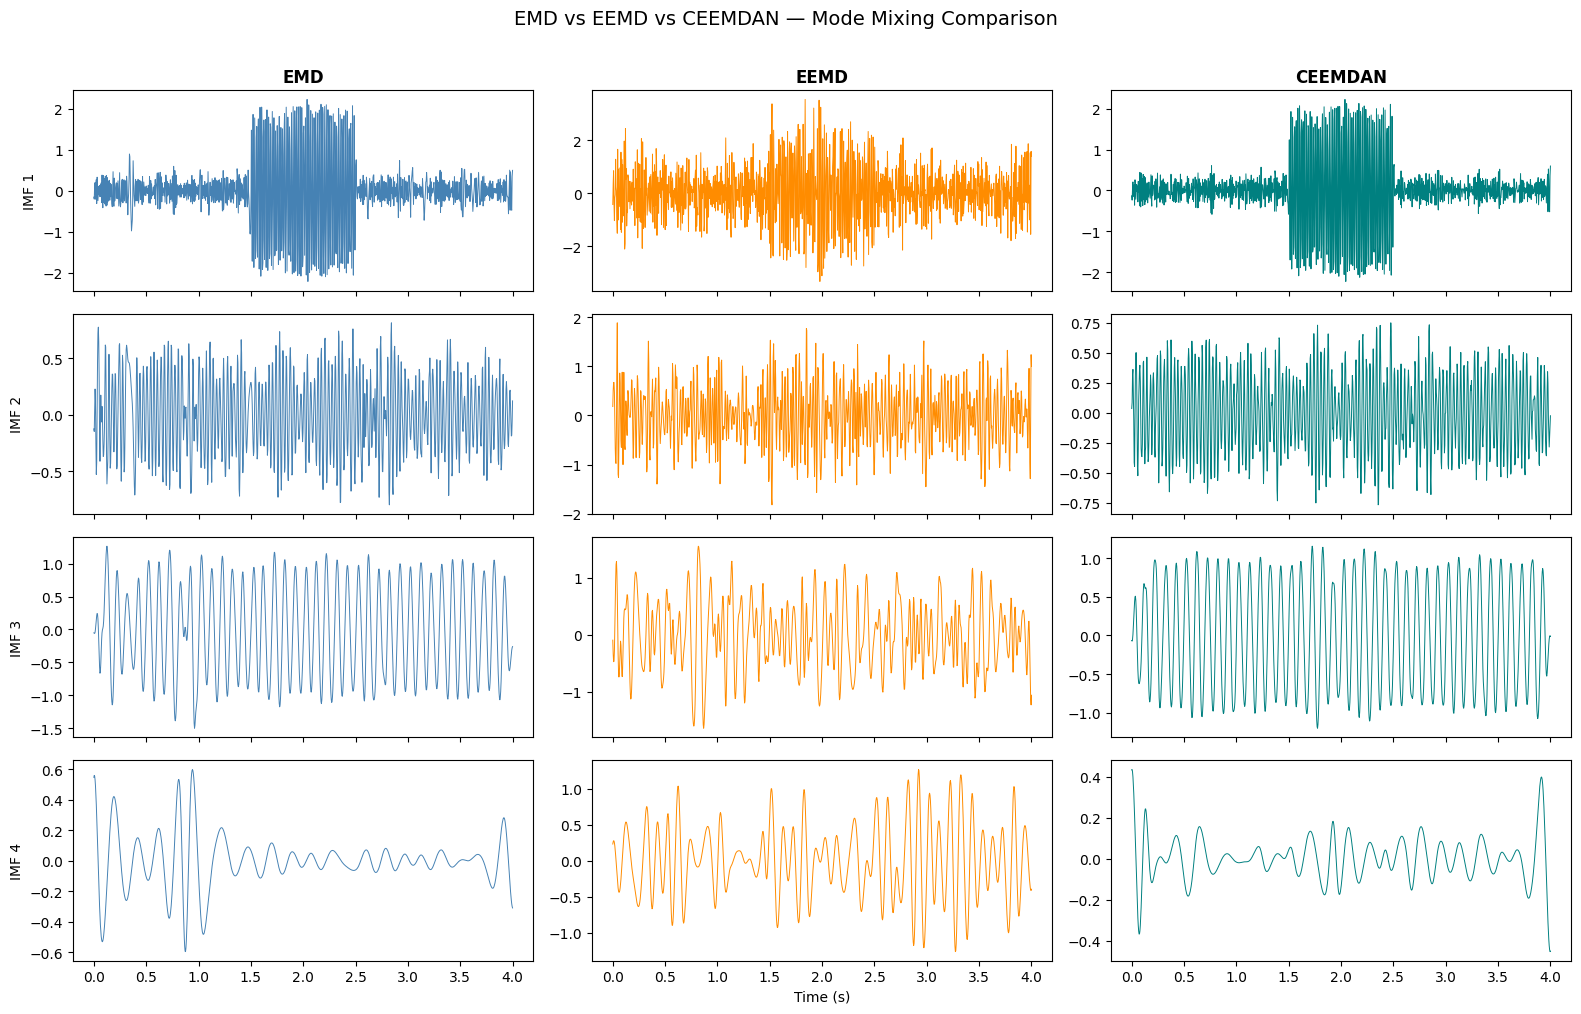

Reconstruction MSE:
  EMD:     0.000000
  EEMD:    0.930218
  CEEMDAN: 0.000000


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PyEMD import EMD, EEMD, CEEMDAN

# --- Synthetic signal with mode-mixing-prone components ---
np.random.seed(7)
fs = 256
t = np.linspace(0, 4, fs * 4)

# Intermittent high-freq burst causes mode mixing in plain EMD
signal = (
    np.sin(2 * np.pi * 10 * t)
    + 0.5 * np.sin(2 * np.pi * 30 * t)
    + np.where((t > 1.5) & (t < 2.5), 2 * np.sin(2 * np.pi * 60 * t), 0)  # intermittent burst
    + 0.3 * np.random.randn(len(t))
)

# --- Run all three methods ---
emd = EMD()
eemd = EEMD(trials=50, noise_width=0.2)
ceemdan = CEEMDAN(trials=50, epsilon=0.2)

imfs_emd = emd.emd(signal, t)
imfs_eemd = eemd.eemd(signal, t)
imfs_ceemdan = ceemdan.ceemdan(signal, t)

# --- Compare first 4 IMFs from each method side-by-side ---
n_show = min(4, imfs_emd.shape[0], imfs_eemd.shape[0], imfs_ceemdan.shape[0])
fig, axes = plt.subplots(n_show, 3, figsize=(16, 2.5 * n_show), sharex=True)

methods = [("EMD", imfs_emd, "steelblue"),
           ("EEMD", imfs_eemd, "darkorange"),
           ("CEEMDAN", imfs_ceemdan, "teal")]

for col, (name, imfs, color) in enumerate(methods):
    for row in range(n_show):
        axes[row, col].plot(t, imfs[row], color=color, linewidth=0.7)
        if row == 0:
            axes[row, col].set_title(name, fontsize=12, fontweight="bold")
        axes[row, 0].set_ylabel(f"IMF {row + 1}", fontsize=10)

axes[-1, 1].set_xlabel("Time (s)")
fig.suptitle("EMD vs EEMD vs CEEMDAN — Mode Mixing Comparison", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# --- Reconstruction error comparison ---
def reconstruction_error(signal, imfs):
    return np.mean((signal - np.sum(imfs, axis=0))**2)

print("Reconstruction MSE:")
print(f"  EMD:     {reconstruction_error(signal, imfs_emd):.6f}")
print(f"  EEMD:    {reconstruction_error(signal, imfs_eemd):.6f}")
print(f"  CEEMDAN: {reconstruction_error(signal, imfs_ceemdan):.6f}")

### 7. Evaluation and Choice of Parameters
These methods (WT, EMD, ICA) are often paired and then evaluated using **Entropy Thresholds** to determine which components are noise and which are signal.

---
**Bottom Line:** Whether using Wavelets or the EMD family (EEMD, CEEMDAN), these techniques can all be cross-paired with ICA to create a robust, multi-stage cleaning pipeline for EEG.